## Loading and cleaning data

In [2]:
import pandas as pd
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.ndimage


# Load data from zip file
zip_path = "data/dmc_122124.zip"
zip_path = "data/dmc_122724.zip"
zip_path = "data/dmc_010225.zip"
zip_path = "data/dmc_010625.zip"
zip_path = "data/dmc_011325.zip"
records = []

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for filename in zip_ref.namelist():
        if filename.endswith('.npy'):
            if not 'online_returns' in filename:
                continue
            # Extract parameters from filename e.g. results/utd_4.0/quadruped-walk/online_returns/bs_272_lr_0.000419_reset_True.npy
            if filename.startswith('__MACOSX'):
                continue
            env_name = filename.split('/')[2]  # Get environment name from path
            name = filename.split('/')[4]  # Get parameters from last part of path
            params = name.split('_')
            batch_size = int(float(params[1]))  # Extract batch size after 'bs_'
            learning_rate = float(params[3])  # Extract learning rate after 'lr_'
            utd_part = filename.split('/')[1]  # Get UTD from second part of path
            utd = float(utd_part.split('utd_')[1])  # Extract UTD value after 'utd_' prefix
            # Load array data
            with zip_ref.open(filename) as f:
                arr = np.load(f)
                
            # Create record with metadata and results
            records.append({ 
                'env_name': env_name,
                'batch_size': batch_size,
                'utd': utd,
                'learning_rate': learning_rate,
                'training_step': np.arange(arr.shape[0]) * 1000 + 5000,
                'return': arr[:, :],
                'mean_return': np.mean(arr[:, :], axis=1),  # Add summary statistics
                # 'return': arr[:, 1:7],
                # 'mean_return': np.mean(arr[:, 1:7], axis=1),
                'std_return': np.std(arr[:, :], axis=1) / np.sqrt(10)  # Standard Error of Mean over 10 seeds
            })

# Convert to pandas DataFrame
df = pd.DataFrame(records)

df['learning_rate'] = df['learning_rate'].replace(1.2e-2, 1.2e-3) # mislabeled in the data

# merge additional seeds for hopper-stand and reacher-easy
for env in ['hopper-stand', 'reacher-easy']:
    base_envs = df[df['env_name'] == env]
    seeds_envs = df[df['env_name'] == f'{env}_seeds']
    
    for i in range(len(base_envs)):
        base_env = base_envs.iloc[i]
        seeds_env = seeds_envs.iloc[i]
        
        # Combine returns arrays
        min_length = min(base_env['return'].shape[0], seeds_env['return'].shape[0])
        merged_returns = np.concatenate([base_env['return'][:min_length], seeds_env['return'][:min_length]], axis=1)
        merged_mean = np.mean(merged_returns, axis=1)
        merged_std = np.std(merged_returns, axis=1)
        training_steps = base_env['training_step'][:min_length]

        # Create new row with merged data
        merged_row = base_env.copy()
        merged_row.update({'env_name': f'{env}_merged', 'training_step': training_steps, 'return': merged_returns, 'mean_return': merged_mean, 'std_return': merged_std})
        df = df.append(merged_row, ignore_index=True)

# drop hopper-stand_seeds and reacher-easy_seeds as well as hopper-stand and reacher-easy
df = df[~df['env_name'].isin(['hopper-stand_seeds', 'reacher-easy_seeds', 'hopper-stand', 'reacher-easy'])]

# Add isotonic regression on return data
from sklearn.isotonic import IsotonicRegression
iso_reg_results = []

for _, row in df.iterrows():
    # Initialize isotonic regression model
    ir = IsotonicRegression(out_of_bounds='clip')
    
    # Fit on training steps and mean returns
    x = row['training_step']
    y = row['mean_return']
    # Bootstrap sampling from returns
    # Sample with replacement from the returns at each timestep
    # bootstrap_samples = np.random.choice(row['return'].shape[1], size=row['return'].shape[1], replace=True)
    # y = np.mean(row['return'][:, bootstrap_samples], axis=1)
    # print(row['mean_return'].shape, row['return'].shape)
    
    # Fit the model and get predictions
    ir.fit(x, y)
    y_iso = ir.predict(x)
    
    iso_reg_results.append(y_iso)

# Add isotonic regression results to dataframe    
df['return_isotonic'] = iso_reg_results

# Calculate crossings for each threshold and store in array
thresholds = [200, 300, 400, 500, 600, 700, 800]

crossings_array = []

for _, row in df.iterrows():
    row_crossings = []
    
    for threshold in thresholds:
        # Get crossing from isotonic regression
        crossing_idx = np.where(row['return_isotonic'] > threshold)[0]
        row_crossings.append(row['training_step'][crossing_idx[0]] if len(crossing_idx) > 0 else np.nan)
    
    crossings_array.append(row_crossings)

df['crossings'] = crossings_array

# Remove hopper-stand_seeds and reacher-easy_seeds
# df = df[~df['env_name'].isin(['hopper-stand_seeds', 'reacher-easy_seeds'])]

# df

In [3]:
# Leave only the best runs 

# Get unique environments and UTD ratios
envs = df['env_name'].unique()
utds = df['utd'].unique()

# Create a filtered dataframe
filtered_rows = []

for env in envs:
    env_data = df[df['env_name'] == env]
    
    # For each UTD value
    for utd in utds:
        utd_data = env_data[env_data['utd'] == utd]
        
        if len(utd_data) > 0:
            # Get middle learning rate
            lrs = sorted(utd_data['learning_rate'].unique())
            mid_lr = lrs[len(lrs)//2]
            
            # Get middle batch size
            batch_sizes = sorted(utd_data['batch_size'].unique())
            mid_bs = batch_sizes[len(batch_sizes)//2]
            
            # Get the row with middle lr and bs
            row = utd_data[
                (utd_data['learning_rate'] == mid_lr) & 
                (utd_data['batch_size'] == mid_bs)
            ]
            
            if len(row) > 0:
                filtered_rows.append(row.iloc[0])

# Create new dataframe with filtered rows
df = pd.DataFrame(filtered_rows)


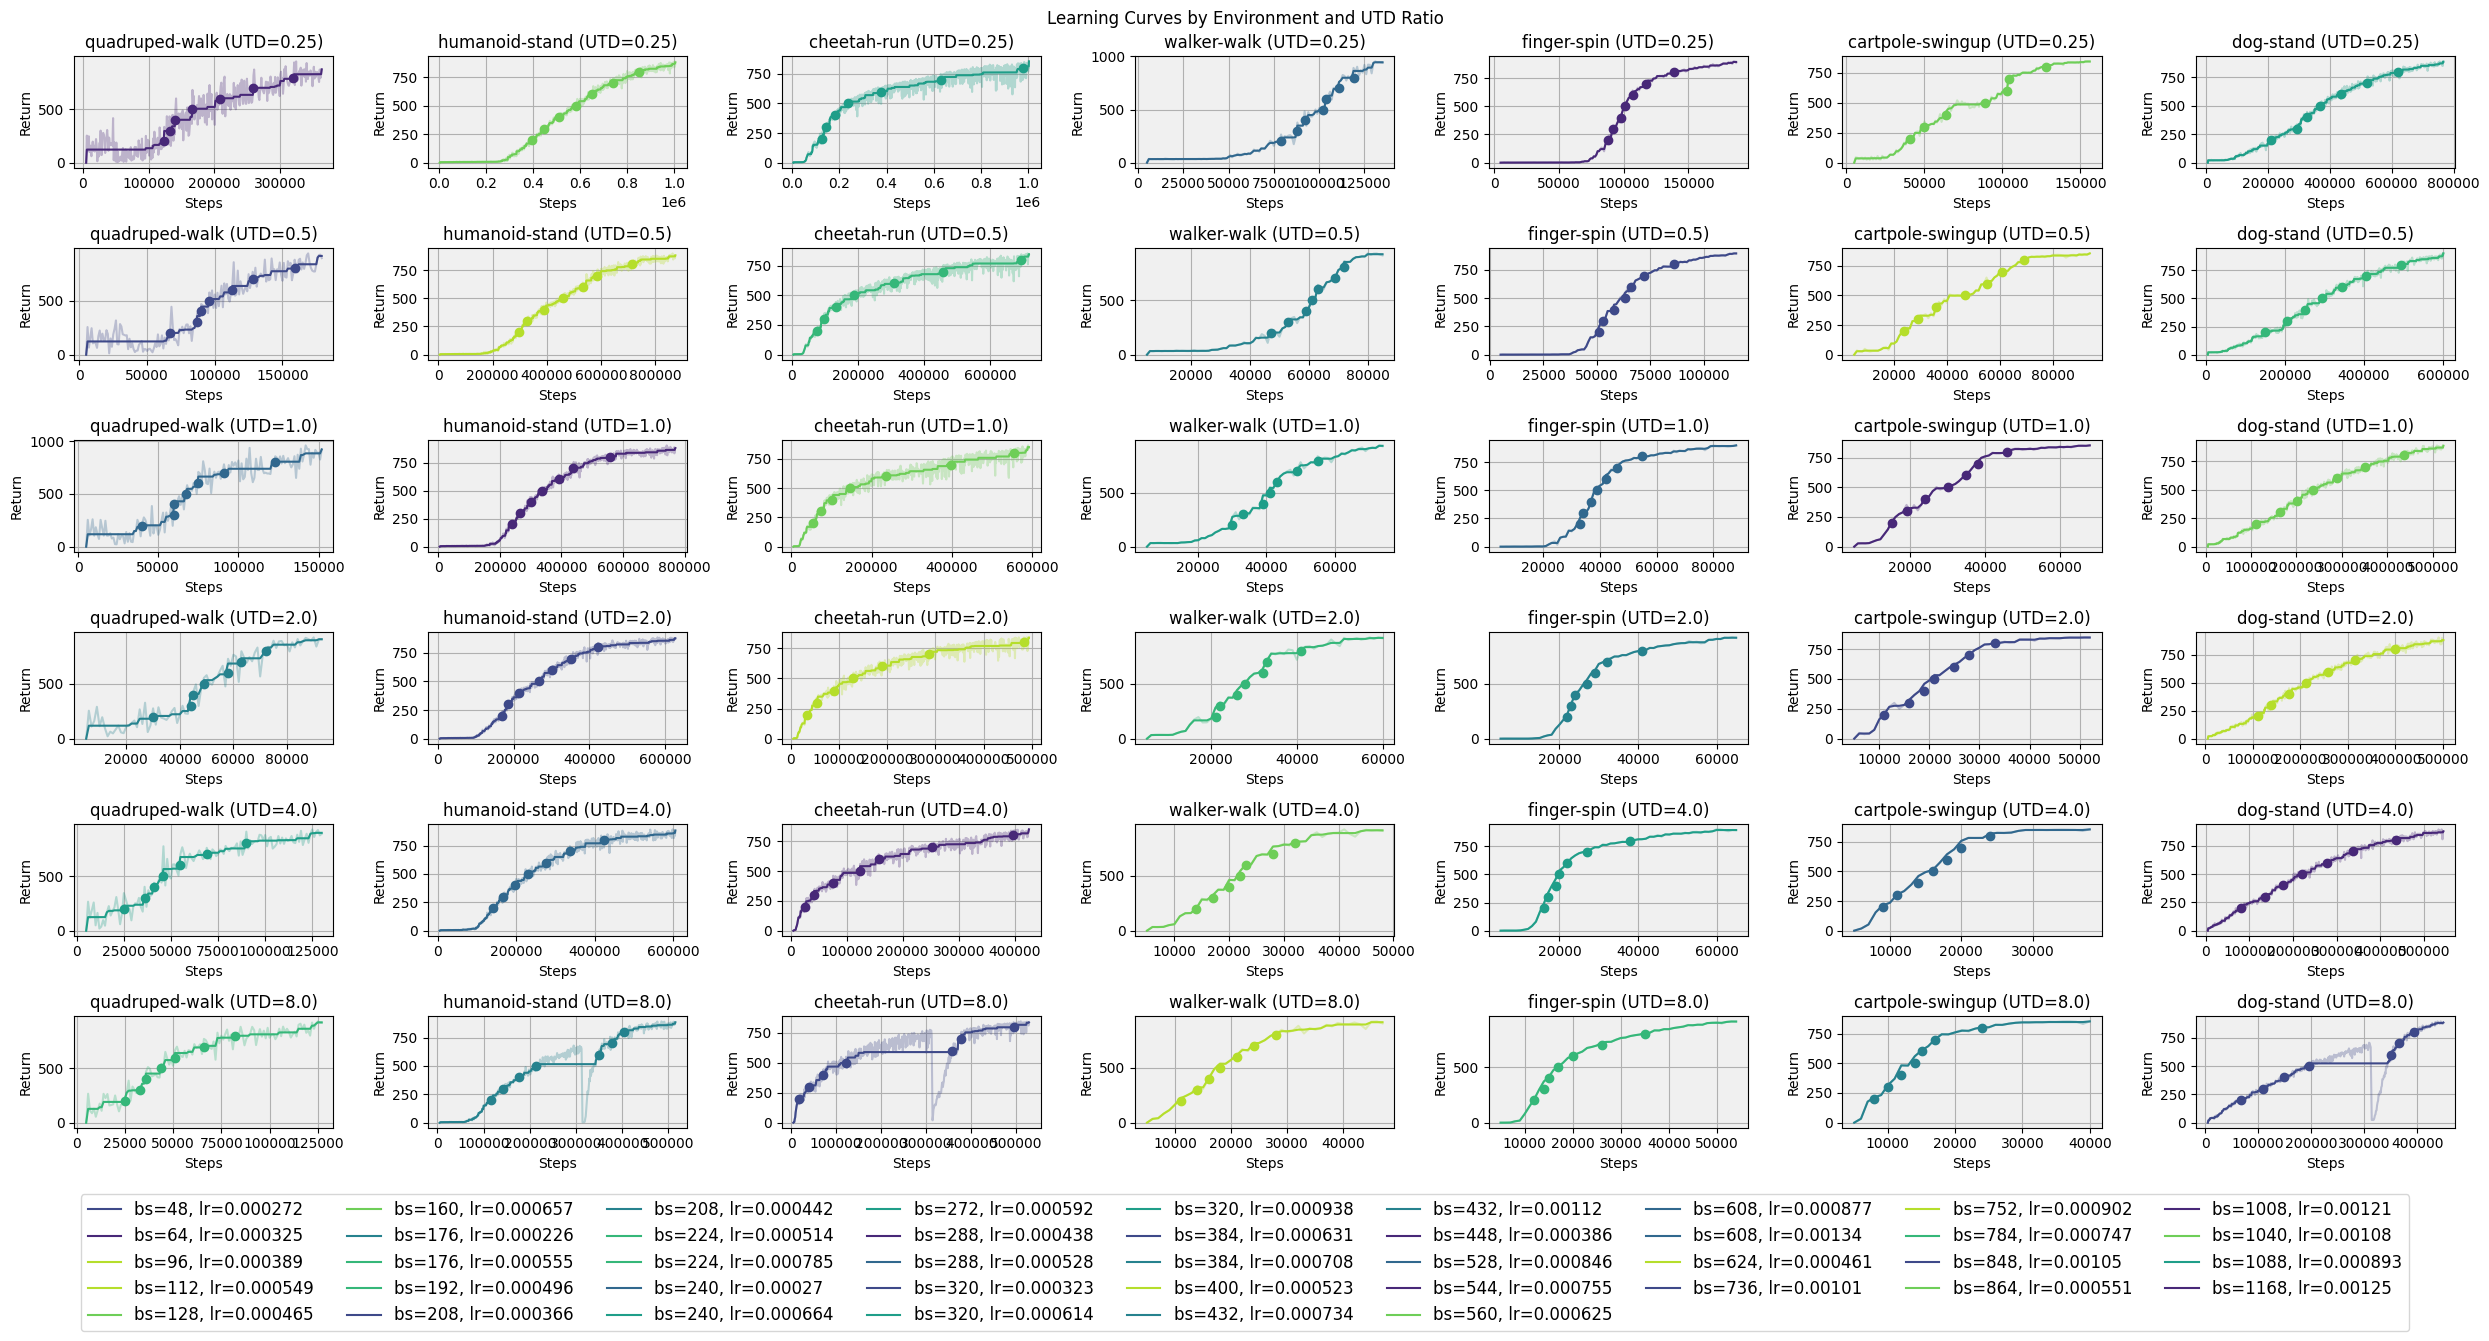

In [4]:
# plot curves for all bs and lr together

colors = sns.color_palette("viridis", n_colors=8)  # Using viridis for a nice gradient
fig, axs = plt.subplots(6, 7, figsize=(25, 12))
fig.suptitle('Learning Curves by Environment and UTD Ratio')

lines = []
labels = []
config_colors = {}
color_idx = 0

df_filtered = df[df['batch_size'] == 64]
df_filtered = df
# df_filtered = df_filtered[df_filtered['learning_rate'] == 3e-4]

# Group data by environment and UTD ratio
for i, env in enumerate(df['env_name'].unique()):
    env_data = df_filtered[df_filtered['env_name'] == env]
    
    # Create separate plots for each UTD value
    for j, utd in enumerate(sorted(env_data['utd'].unique())):
        utd_data = env_data[env_data['utd'] == utd]
        # Sort by batch size and learning rate
        utd_data = utd_data.sort_values(['utd', 'batch_size', 'learning_rate'])
        
        ax = axs[j, i]
        ax.set_title(f'{env} (UTD={utd})')
        
        for _, row in utd_data.iterrows():
            config = (row['batch_size'], row['learning_rate'])
            if config not in config_colors:
                config_colors[config] = color_idx
                color_idx += 1
            
            label = f"bs={row['batch_size']}, lr={row['learning_rate']}"
            line = ax.plot(row['training_step'], row['mean_return'], alpha=0.3, color=colors[config_colors[config] % len(colors)])
            line = ax.plot(row['training_step'], row['return_isotonic'], alpha=1, color=colors[config_colors[config] % len(colors)])
            # results = scipy.ndimage.gaussian_filter1d(row['mean_return'], smoothing[env, row['utd']])
            # line = ax.plot(row['training_step'], results, alpha=1, color=colors[config_colors[config] % len(colors)])

            # use the crossings column to plot crossings
            for k, threshold in enumerate(thresholds):
                # crossing_x = row['crossings'][k]
                crossing_x = row['crossings'][k]
                crossing_y = threshold
                ax.plot(crossing_x, crossing_y, 'o', color=colors[config_colors[config] % len(colors)])
            # Plot crossing standard deviations as error bars
            for k, threshold in enumerate(thresholds):
                crossing_x = row['crossings'][k]
                crossing_y = threshold
                ax.errorbar(crossing_x, crossing_y, color=colors[config_colors[config] % len(colors)], capsize=3)
            
            # Only add to legend if we haven't seen this combination before
            if label not in labels:
                lines.append(line[0])
                labels.append(label)
        
        ax.set_xlabel('Steps')
        ax.set_ylabel('Return')
        ax.grid(True)
        
        # Set background color
        ax.set_facecolor('#f0f0f0')

# Sort labels by batch size and learning rate
sorted_indices = [i for i, _ in sorted(enumerate(labels), 
                                     key=lambda x: tuple(map(float, x[1].replace("bs=","").replace("lr=","").split(", "))))]
lines = [lines[i] for i in sorted_indices]
labels = [labels[i] for i in sorted_indices]

# Create a single legend outside all subplots
fig.legend(lines, labels, bbox_to_anchor=(0.5, 0), loc='upper center', ncol=9, fontsize=12)
plt.tight_layout()
plt.show()

## Data efficiency

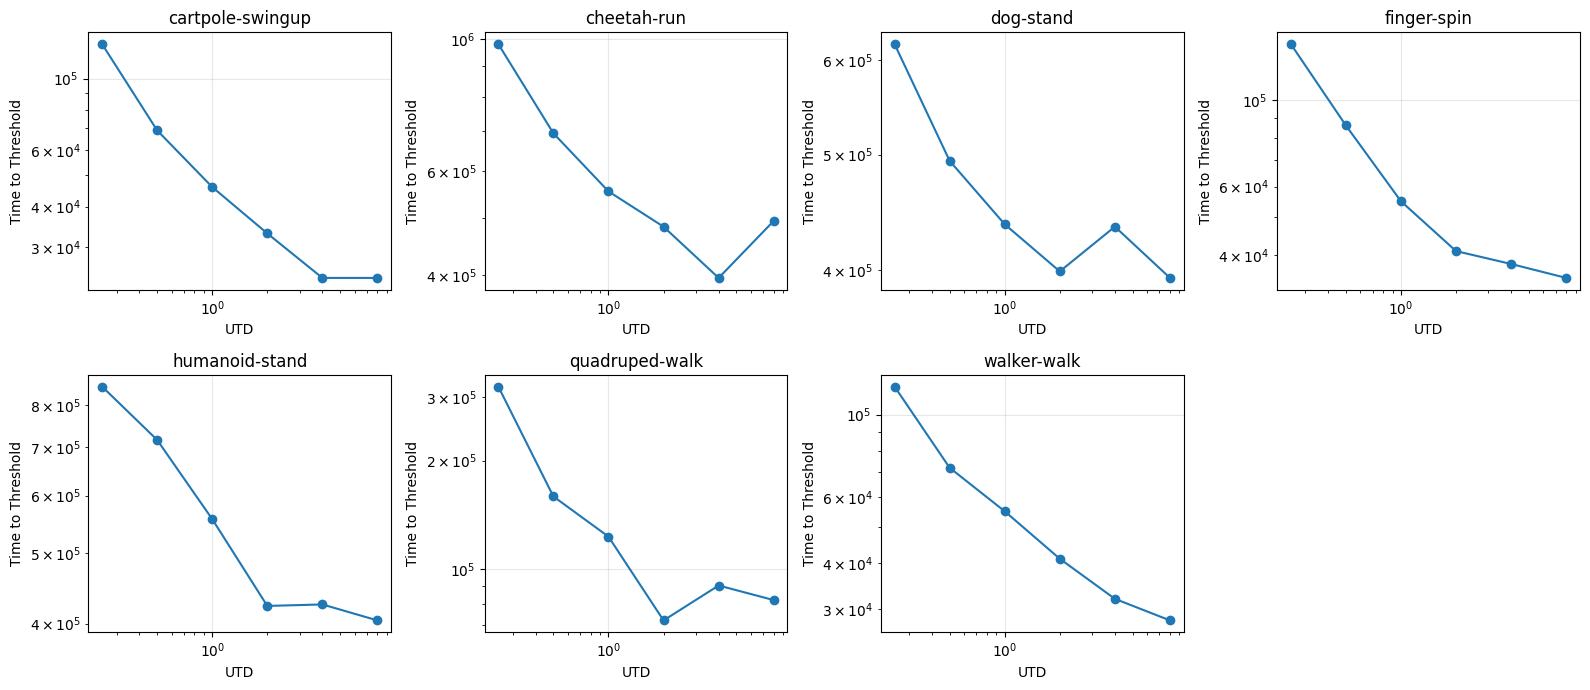

In [5]:
# For a particular threshold, get utds and times

# Plot time to threshold for each environment
# envs = sorted([env for env in df['env_name'].unique() if env not in ['cheetah-run', 'humanoid-stand', 'dog-stand']])
envs = sorted([env for env in df['env_name'].unique()])
n_cols = 4
n_rows = (len(envs) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

env_data_dict = {}

for i, env in enumerate(envs):
    env_df = df[df['env_name'] == env]
    
    # Get UTD and crossing times for this environment, sorted by UTD
    utds = sorted(env_df['utd'].values)
    # Save all thresholds instead of just the last one
    times = [env_df[env_df['utd'] == utd]['crossings'].iloc[0][:-1] for utd in utds]
    env_data_dict[env] = list(zip(utds, times))
    
    # Plot if we have data
    if len(utds) > 0:
        axes[i].plot(utds, times, 'o-')
        axes[i].set_xlabel('UTD')
        axes[i].set_ylabel('Time to Threshold') 
        axes[i].set_title(env)
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for j in range(len(envs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


[ 24000. 151500. 268000.  36000. 344000.  67000.  33000.] 67000.0 (7,)
False 1.406 1.421
(6,) (7, 6, 7)


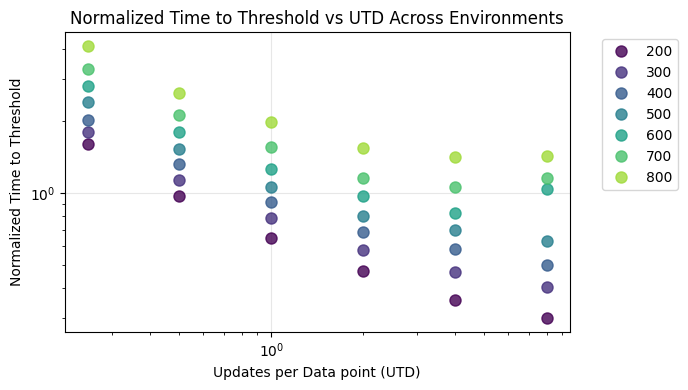

In [6]:
# Plot all environments on one plot
plt.figure(figsize=(7, 4))

# Calculate median times and scaling factors for each environment
median_times = np.array([np.median(list(zip(*env_data_dict[env]))[1]) for env in envs if len(env_data_dict[env]) > 0])
median_median = np.median(median_times)
scaling = 1 / median_times
print(median_times, median_median, median_times.shape)

# Store the normalized data for each environment
normalized_times_all = []
for i, env in enumerate(envs):
    if len(env_data_dict[env]) > 0:
        utds, times = zip(*env_data_dict[env])
        normalized_times = np.array(times) * scaling[i]
        normalized_times_all.append(normalized_times)
        # plt.plot(utds, normalized_times, '--', label=env, alpha=0.5)

# Calculate and plot the average across all environments    
normalized_times_all = np.array(normalized_times_all)
mean_normalized_times = np.mean(normalized_times_all, axis=0)
print(mean_normalized_times[-2, -1] > mean_normalized_times[-1, -1], f'{mean_normalized_times[-2, -1]:.3f}', f'{mean_normalized_times[-1, -1]:.3f}')
n_thresholds = mean_normalized_times.shape[-1]

for i in range(n_thresholds):
    plt.plot(utds, mean_normalized_times[:, i], 'o', color=plt.cm.viridis(i/n_thresholds), 
             label=f'{thresholds[i]}', markersize=8, alpha=0.8)
    

# plt.scatter(utds, np.mean(normalized_times_all, axis=0), c=utds, cmap='viridis', s=100, label='Average', alpha=0.8)

# Fit a line to log-transformed data
log_utds = np.log(utds)
print(np.array(utds).shape, np.array(normalized_times_all).shape)
log_mean_times = np.log(np.mean(normalized_times_all, axis=0))
slope, intercept = np.polyfit(log_utds, log_mean_times[:, -1], 1)

# # Plot the fit line
# fit_x = np.array([min(utds), max(utds)])
# fit_y = np.exp(slope * np.log(fit_x) + intercept)
# plt.plot(fit_x, fit_y, 'k-', linewidth=2, 
#          label=f'y = {np.exp(intercept):.2f} * x^{slope:.2f}')

plt.xlabel('Updates per Data point (UTD)')
plt.ylabel('Normalized Time to Threshold')
plt.title('Normalized Time to Threshold vs UTD Across Environments')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Asymptotic data efficiency fit

In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from ast import arg
import matplotlib.pyplot as plt
from tqdm import tqdm

import scipy

def fit(xs, y, optim_f, init_grid, top_k=500, n_proc=8, tol=None, disp=False, maxiter=None):
        _, _, brute_xs, brute_ys = scipy.optimize.brute(optim_f, init_grid, args=(xs, y), full_output=True, finish=None, Ns=1, workers=-1)

        brute_xs = brute_xs.reshape(brute_xs.shape[0], -1)
        brute_ys = brute_ys.reshape(-1)

        top_idxs = np.argsort(brute_ys)[:top_k]
        top_xs = brute_xs[:, top_idxs]
        # top_ys = brute_ys[top_idxs]
        preds = []
        for i in tqdm(range(top_xs.shape[1])):
            options = {'disp': disp}
            if maxiter: options['maxiter'] = maxiter
            pred = scipy.optimize.minimize(optim_f, top_xs[:, i], args=(xs, y), method='L-BFGS-B', tol=tol, options=options).x
            loss = optim_f(pred, xs, y)
            # print(pred, loss)
            preds.append((pred, loss))
        return sorted(preds, key=lambda x: x[1])[0][0]

def power_law_with_const_min(args, *params):
    x,y = params
    a,b,c = args
    # return ((power_law_with_const(x,a,b,c) - y) ** 2).mean()
    with np.errstate(invalid='ignore', divide='ignore'):
        return ((np.log(power_law_with_const(x,a,b,c) / y)) ** 2).mean()

def power_law_with_const(x, a, b, c): return c * (1 + (x/b)**(-a))


In [8]:
# Pareto fit

# Plot mean data points
fits = []
for i in range(n_thresholds):
    # Fit power law with constant for each threshold
    params = fit(utds[:-1], mean_normalized_times[:-1, i], power_law_with_const_min,[slice(-2, 2, 0.8), slice(0, 1, 0.2), slice(-2, 2, 0.8)], maxiter=100)
    # params = fit(utds, mean_normalized_times[:, i], power_law_with_const_min,[slice(-2, 2, 4), slice(0, 1, 1), slice(-2, 2, 4)], maxiter=100)

    a, b, c = params
    fits.append(params)


  0%|          | 0/125 [00:00<?, ?it/s]/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/ipykernel_launcher.py:37: RuntimeWarning: overflow encountered in power
/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/ipykernel_launcher.py:37: RuntimeWarning: overflow encountered in multiply
 34%|███▍      | 43/125 [00:00<00:00, 127.28it/s]/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/scipy/optimize/_numdiff.py:557: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
100%|██████████| 125/125 [00:00<00:00, 171.37it/s]


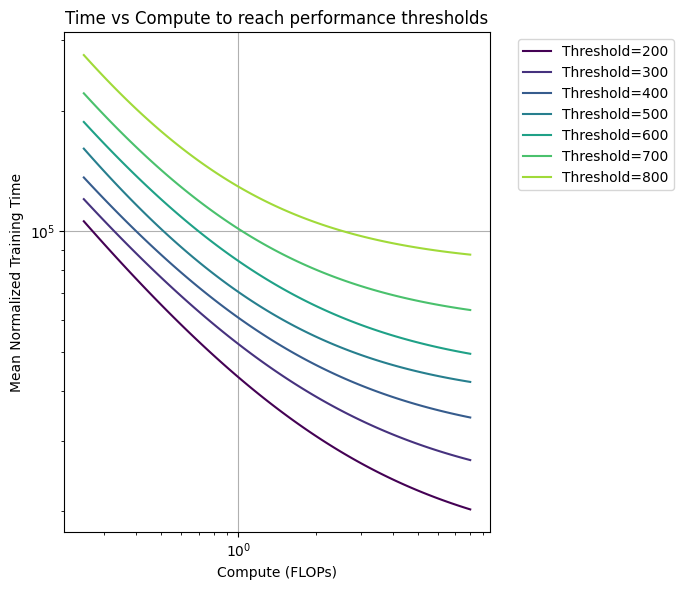

In [9]:
# Plot pareto fits

plt.figure(figsize=(7, 6))

for i in (range(n_thresholds)):
    # Generate smooth curves and plot fits for each threshold
    x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
    a, b, c = fits[i]
    y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
    utd = x_smooth
    data = y_fitted

    # Convert UTD ratio to compute using the formula from dmc_data5_fits.ipynb
    grad_steps = utd * data
    batch_sizes = 400 * (utd)**(-0.3)
    compute = grad_steps * batch_sizes * 10 * 4.92e6
    
    # Plot the fit
    plt.plot(utd, data, '-',
             color=plt.cm.viridis(i/n_thresholds), 
             label=f'Threshold={thresholds[i]}')
    # plt.plot(compute, data, '-',
    #          color=plt.cm.viridis(i/n_thresholds), 
    #          label=f'Threshold={thresholds[i]}')
    
    # # Plot the asymptote
    # plt.axhline(y=c * median_median,
    #             color=plt.cm.viridis(i/n_thresholds),
    #             linestyle='--',
    #             label=f'Asymptote {i}')

plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.xlabel('Compute (FLOPs)')
plt.ylabel('Mean Normalized Training Time')
plt.title('Time vs Compute to reach performance thresholds')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Save fits
np.save('fits.npy', fits)

## Plotting

In [10]:
from rliable import plot_utils
COLORS = ['#BBCC33', '#77AADD', '#44BB99',
           '#EEDD88', '#EE8866', '#FFAABB',
          '#99DDFF', '#44BB99', '#AAAA00',
          '#DDDDDD']
palette = sns.set_palette(COLORS)
plt.rcParams['text.usetex'] = False #Let TeX do the typsetting
plt.rcParams['text.latex.preamble'] = r'\usepackage{sansmath} \sansmath' #Force sans-serif math mode (for axes labels)
plt.rcParams['font.family'] = 'sans-serif' # ... for regular text
plt.rcParams['font.sans-serif'] = ['Helveta Nue'] # Choose a nice font here
sns.set_style("whitegrid")


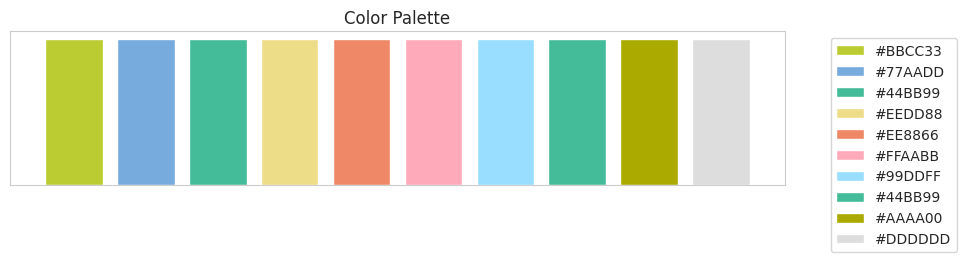

In [11]:
plt.figure(figsize=(10,2))
for i, color in enumerate(COLORS):
    plt.bar(i, 1, color=color, label=color)
plt.xticks([])
plt.yticks([])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Color Palette')
plt.show()



y = 1.22 * (1 + (x/0.59)**(-1.01)


<AxesSubplot:xlabel='UTD Ratio - $\\sigma$', ylabel='Data until $f$ - $\\mathcal{D}_f$ (×1000)'>

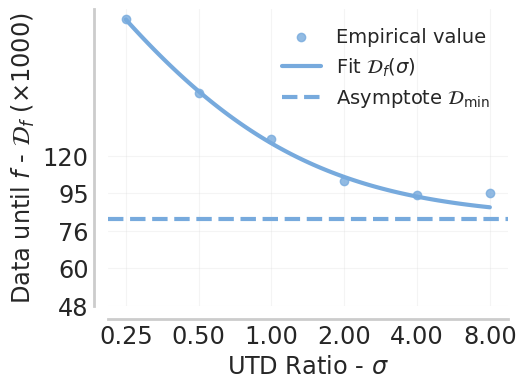

In [12]:
# Pareto fit 

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2, 369.6/192*2)


a, b, c = fits[-1]
print(f'y = {c:.2f} * (1 + (x/{b:.2f})**(-{a:.2f})')
data = power_law_with_const(x_smooth, a, b, c) * median_median
utd_line = x_smooth
data_line = y_fitted
plt.scatter(utds, np.mean(normalized_times_all[..., -1], axis=0) * median_median, marker='o', color=COLORS[1], label='Empirical value', alpha=0.8)
# plt.scatter(utds, np.mean(normalized_times_all[..., -1], axis=0), marker='o', color=COLORS[1], label='Empirical value', alpha=0.8)
plt.plot(utd_line, data_line, COLORS[1], linewidth=3, label='Fit $\mathcal{D}_f(\sigma)$')

# Plot the asymptote
plt.axhline(y=c * median_median, color=COLORS[1], linewidth=3, linestyle='--', label='Asymptote $\mathcal{D}_{\mathrm{min}}$')

plt.xscale('log')
plt.yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False)

x = np.logspace(np.log10(0.25), np.log10(8), num=6)
x_ticks_labels = [f"{x:.2f}" for x in x]
axs.set_xticks(x,x_ticks_labels)

yticks = np.logspace(np.log10(48000), np.log10(120000), num=5, dtype=int)
ylabels = ["%2.f" % (y/1000) for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='UTD Ratio - $\sigma$',
                                       ylabel='Data until $f$ - $\mathcal{D}_f$ (×1000)',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)


[20000.         18301.87149477 16567.69748429 14796.7128448
 12988.13621158 11141.16963418  9254.99822436  7328.78979658
  5361.69450083  3352.84444764  1301.35332523]
[80000.         78301.87149477 76567.69748429 74796.7128448
 72988.13621158 71141.16963418 69254.99822436 67328.78979658
 65361.69450083 63352.84444764 61301.35332523 59206.31600841
 57066.80815925 54881.88581926 52650.58499293 50371.92122239
 48044.88915307 45668.46209013 43241.59154548 40763.20677521
 38232.21430712 35647.49745833 33007.91584254 30312.30486697
 27559.47521843 24748.21233869 21877.27588856 18945.39920064
 15951.2887205  12893.62343593  9771.05429413  6582.20360646
  3325.66444064]
[240000.         238301.87149477 236567.69748429 234796.7128448
 232988.13621158 231141.16963418 229254.99822436 227328.78979658
 225361.69450083 223352.84444764 221301.35332523 219206.31600841
 217066.80815925 214881.88581926 212650.58499293 210371.92122239
 208044.88915307 205668.46209013 203241.59154548 200763.20677521
 198

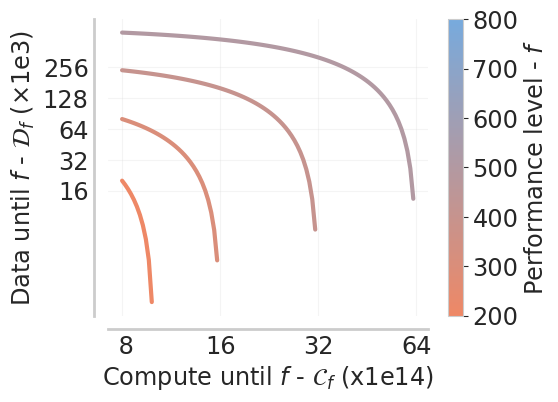

In [13]:
# Plot pareto fits

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2, 369.6/192*2)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("custom_gradient", [COLORS[4], COLORS[1]])
n_colors = n_thresholds
colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]

budget_thresholds = np.array([10e14, 16e14, 32e14, 64e14])

for i, budget_threshold in enumerate(budget_thresholds):
    # Generate points for the line compute + beta*data = threshold
    x_range = np.logspace(np.log10(8e14), np.log10(64e14), 100)
    beta = 1e10  # Coefficient for y term
    y_range = (budget_thresholds[i] - x_range) / beta
    
    # Only plot points where y is positive
    compute = x_range[y_range > 0]
    data = y_range[y_range > 0]
    print(data)

    # Plot the line
    plt.plot(compute, data, '-',
             color=colors[i], 
             label=f'Threshold={budget_thresholds[i]}',
             linewidth=3)

plt.xscale('log')
plt.yscale('log')
# axs.legend(prop={'size': 14}, ncol=1, frameon=False)

x = np.logspace(np.log10(8e14), np.log10(64e14), num=4, dtype=int)
xlabels = ["%2.f" % (y/1e14) for y in x]
axs.xaxis.set_major_locator(plt.FixedLocator(x))
axs.xaxis.set_minor_locator(plt.NullLocator()) 
axs.set_xticks(x, xlabels, size=14.5)

yticks = np.logspace(np.log10(16000), np.log10(256000), num=5, dtype=int)
ylabels = ["%2.f" % (y/1000) for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='Compute until $f$ - $\mathcal{C}_f$ (x1e14)',
                                       ylabel='Data until $f$ - $\mathcal{D}_f$ (×1e3)',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)

# Save fits
np.save('fits.npy', fits)
# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Performance level - $f$', size='xx-large')
cbar.ax.tick_params(labelsize='xx-large')


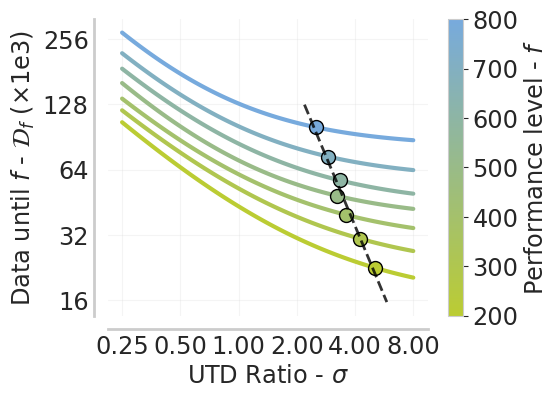

In [15]:
# Plot multiple pareto fits

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2, 369.6/192*2)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("custom_gradient", [COLORS[0], COLORS[1]])
n_colors = n_thresholds
colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]

min_points_x = []
min_points_y = []

for i in (range(n_thresholds)):
    # Generate smooth curves and plot fits for each threshold
    x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
    a, b, c = fits[i]
    y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
    utd = x_smooth
    data = y_fitted

    # Convert UTD ratio to compute using the formula from dmc_data5_fits.ipynb
    grad_steps = utd * data
    batch_sizes = 400 * (utd)**(-0.3)
    compute = grad_steps * batch_sizes * 10 * 4.92e6
    
    # Plot the fit
    plt.plot(utd, data, '-',
             color=colors[i],
             label=f'Threshold={thresholds[i]}',
             linewidth=3)
    
    # Find and mark minimum point
    beta = 1e11
    min_idx = np.argmin(compute + beta * data)
    plt.plot(utd[min_idx], data[min_idx], 'o',
             color=colors[i],
             markersize=10,
             markeredgecolor='black')

    # Store min points for fitting line
    min_points_x.append(utd[min_idx])
    min_points_y.append(data[min_idx])
    
# UTD extrapolation line
min_points_x = np.array(min_points_x)
min_points_y = np.array(min_points_y)
# Fit line in log space
coeffs = np.polyfit(np.log10(min_points_x), np.log10(min_points_y), 1)
# Generate points for the fitted line
x_range = np.log10(min(min_points_x)), np.log10(max(min_points_x))
x_line = np.logspace(x_range[0] - 0.2 * (x_range[1] - x_range[0]), x_range[1] + 0.2 * (x_range[1] - x_range[0]), 100)
y_line = 10**(coeffs[0] * np.log10(x_line) + coeffs[1])
plt.plot(x_line, y_line, '--k', linewidth=2, alpha=0.8)
    

plt.xscale('log')
plt.yscale('log')
# axs.legend(prop={'size': 14}, ncol=1, frameon=False)

# x = np.logspace(np.log10(8e14), np.log10(64e14), num=4, dtype=int)
# xlabels = ["%2.f" % (y/1e14) for y in x]
# axs.xaxis.set_major_locator(plt.FixedLocator(x))
# axs.xaxis.set_minor_locator(plt.NullLocator()) 
# axs.set_xticks(x, xlabels, size=14.5)

x = np.logspace(np.log10(0.25), np.log10(8), num=6)
x_ticks_labels = [f"{x:.2f}" for x in x]
axs.set_xticks(x,x_ticks_labels)


yticks = np.logspace(np.log10(16000), np.log10(256000), num=5, dtype=int)
ylabels = ["%2.f" % (y/1000) for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='UTD Ratio - $\sigma$',
                                       ylabel='Data until $f$ - $\mathcal{D}_f$ (×1e3)',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)

# Save fits
np.save('fits.npy', fits)
# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Performance level - $f$', size='xx-large')
cbar.ax.tick_params(labelsize='xx-large')


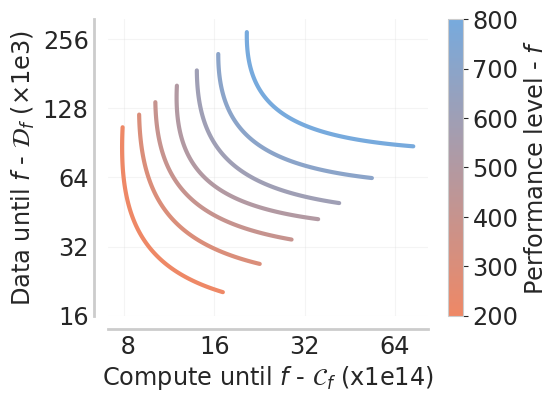

In [15]:
# Plot multiple pareto fits

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2, 369.6/192*2)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("custom_gradient", [COLORS[4], COLORS[1]])
n_colors = n_thresholds
colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]

for i in (range(n_thresholds)):
    # Generate smooth curves and plot fits for each threshold
    x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
    a, b, c = fits[i]
    y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
    utd = x_smooth
    data = y_fitted

    # Convert UTD ratio to compute using the formula from dmc_data5_fits.ipynb
    grad_steps = utd * data
    batch_sizes = 400 * (utd)**(-0.3)
    compute = grad_steps * batch_sizes * 10 * 4.92e6
    


    # Plot the fit
    plt.plot(compute, data, '-',
             color=colors[i],
             label=f'Threshold={thresholds[i]}',
             linewidth=3)

plt.xscale('log')
plt.yscale('log')
# axs.legend(prop={'size': 14}, ncol=1, frameon=False)

x = np.logspace(np.log10(8e14), np.log10(64e14), num=4, dtype=int)
xlabels = ["%2.f" % (y/1e14) for y in x]
axs.xaxis.set_major_locator(plt.FixedLocator(x))
axs.xaxis.set_minor_locator(plt.NullLocator()) 
axs.set_xticks(x, xlabels, size=14.5)

# x = np.logspace(np.log10(0.25), np.log10(8), num=6)
# x_ticks_labels = [f"{x:.2f}" for x in x]
# axs.set_xticks(x,x_ticks_labels)


yticks = np.logspace(np.log10(16000), np.log10(256000), num=5, dtype=int)
ylabels = ["%2.f" % (y/1000) for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='Compute until $f$ - $\mathcal{C}_f$ (x1e14)',
                                       ylabel='Data until $f$ - $\mathcal{D}_f$ (×1e3)',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)

# Save fits
np.save('fits.npy', fits)
# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Performance level - $f$', size='xx-large')
cbar.ax.tick_params(labelsize='xx-large')


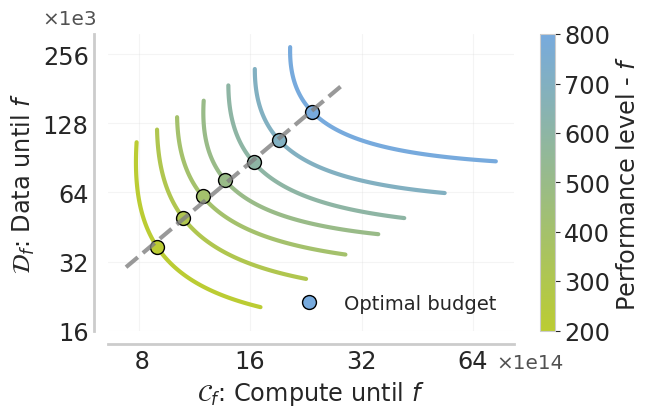

In [17]:
# Plot pareto fits

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2 * 1.27, 369.6/192*2)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("custom_gradient", [COLORS[0], COLORS[1]])
n_colors = n_thresholds
colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]


min_points_compute = []
min_points_data = []
min_points_utd = []

for i in (range(n_thresholds)):
    # Generate smooth curves and plot fits for each threshold
    x_smooth = np.logspace(np.log10(0.25), np.log10(8), 100)
    a, b, c = fits[i]
    y_fitted = power_law_with_const(x_smooth, a, b, c) * median_median
    utd = x_smooth
    data = y_fitted

    # Convert UTD ratio to compute using the formula from dmc_data5_fits.ipynb
    grad_steps = utd * data
    batch_sizes = 400 * (utd)**(-0.3)
    compute = grad_steps * batch_sizes * 10 * 4.92e6
    
    # Plot the fit
    plt.plot(compute, data, '-',
             color=colors[i],
            #  label='$\mathcal{D}_f(\mathcal{C}_f)$' if i == len(thresholds) - 1 else None,
             linewidth=3)
    
    # Find and mark minimum point
    beta = 1e10
    min_idx = np.argmin(compute + beta * data)
    plt.plot(compute[min_idx], data[min_idx], 'o',
                color=colors[i],
                markersize=10,
                label='Optimal budget' if i == len(thresholds) - 1 else None,
                markeredgecolor='black',
                )
    
    # Store min points for fitting line
    min_points_compute.append(compute[min_idx])
    min_points_data.append(data[min_idx])
    min_points_utd.append(utd[min_idx])
    
    utds = np.array(utds)
    data_points = np.mean(normalized_times_all[..., i], axis=0) * median_median
    compute_points = utds * data_points * 400 * utds**(-0.3) * 10 * 4.92e6
    # plt.scatter(compute_points[:-1], data_points[:-1], marker='o', color=COLORS[1], label='Empirical value', alpha=0.8)
    
    
# UTD extrapolation line
min_points_utd = np.array(min_points_utd)
min_points_data = np.array(min_points_data)
min_points_compute = np.array(min_points_compute)
# Fit line in log space
coeffs = np.polyfit(np.log10(min_points_compute), np.log10(min_points_data), 1)
# Generate points for the fitted line
x_range = np.log10(min(min_points_compute)), np.log10(max(min_points_compute))
x_line = np.logspace(x_range[0] - 0.2 * (x_range[1] - x_range[0]), x_range[1] + 0.2 * (x_range[1] - x_range[0]), 100)
y_line = 10**(coeffs[0] * np.log10(x_line) + coeffs[1])
plt.plot(x_line, y_line, '--', color='gray', 
        #  label='Optimal budget fit',
        linewidth=3, alpha=0.8)
    

plt.xscale('log')
plt.yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False, loc='lower right')

x = np.logspace(np.log10(8e14), np.log10(64e14), num=4, dtype=int)
xlabels = ["%2.f" % (y/1e14) for y in x]
axs.xaxis.set_major_locator(plt.FixedLocator(x))
axs.xaxis.set_minor_locator(plt.NullLocator()) 
axs.set_xticks(x, xlabels, size=14.5)

# x = np.logspace(np.log10(0.25), np.log10(8), num=6)
# x_ticks_labels = [f"{x:.2f}" for x in x]
# axs.set_xticks(x,x_ticks_labels)


yticks = np.logspace(np.log10(16000), np.log10(256000), num=5, dtype=int)
ylabels = ["%2.f" % (y/1000) for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='$\mathcal{C}_f$: Compute until $f$',
                                       ylabel='$\mathcal{D}_f$: Data until $f$',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)

plt.text(1.12, -0.14, '×1e14', transform=axs.transAxes, 
         horizontalalignment='right', verticalalignment='bottom',
         fontsize='x-large', alpha=0.8)
plt.text(-0.025, 1.02, '×1e3', transform=axs.transAxes,
         horizontalalignment='right', verticalalignment='bottom', 
         fontsize='x-large', alpha=0.8)




# Save fits
# np.save('fits.npy', fits)
# # Add colorbar
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
# sm.set_array([])
# cbar = plt.colorbar(sm)
# cbar.set_label('Performance level - $f$', size='xx-large')
# cbar.ax.tick_params(labelsize='xx-large')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(thresholds), vmax=max(thresholds)))
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Performance level - $f$', size='xx-large')
cbar.ax.tick_params(labelsize='xx-large')



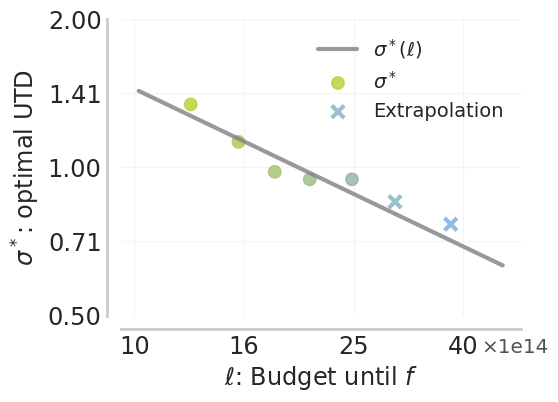

In [19]:
# Plot pareto fits

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2 , 369.6/192*2)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("custom_gradient", [COLORS[0], COLORS[1]])
n_colors = n_thresholds
colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]

# Fit line in log space

min_points_budget = min_points_compute + beta * min_points_data
fit_points = [0,1,2,3,4]
coeffs = np.polyfit(np.log10(min_points_budget[fit_points]), np.log10(min_points_utd[fit_points]), 1)
# Generate points for the fitted line
budget_range = np.log10(min(min_points_budget)), np.log10(max(min_points_budget))
budget_line = np.logspace(budget_range[0] - 0.2 * (budget_range[1] - budget_range[0]), budget_range[1] + 0.2 * (budget_range[1] - budget_range[0]), 100)
utd_line = 10**(coeffs[0] * np.log10(budget_line) + coeffs[1])
plt.plot(budget_line, utd_line, color='gray', linewidth=3, alpha=0.8, label='$\sigma^*(\ell)$')
plt.scatter(min_points_budget[:-2], min_points_utd[:-2], marker='o', color=colors[:-2], label='$\sigma^*$', alpha=0.8, s=80)
plt.scatter(min_points_budget[-2:], min_points_utd[-2:], marker='x', color=colors[-2:], label='Extrapolation', alpha=0.8, s=80, linewidth=3)
    

plt.xscale('log')
plt.yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False)


x = np.logspace(np.log10(10e14), np.log10(40e14), num=4, dtype=int)
xlabels = ["%2.f" % (y/1e14) for y in x]
axs.xaxis.set_major_locator(plt.FixedLocator(x))
axs.xaxis.set_minor_locator(plt.NullLocator()) 
axs.set_xticks(x, xlabels, size=14.5)

# x = np.logspace(np.log10(0.25), np.log10(8), num=6)
# x_ticks_labels = [f"{x:.2f}" for x in x]
# axs.set_xticks(x,x_ticks_labels)

yticks = np.logspace(np.log10(0.5), np.log10(2), num=5)
ylabels = ["%2.2f" % (y) for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='$\ell$: Budget until $f$',
                                       ylabel='$\sigma^*$: optimal UTD',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)

plt.text(1.07, -0.14, '×1e14', transform=axs.transAxes, 
         horizontalalignment='right', verticalalignment='bottom',
         fontsize='x-large', alpha=0.8)

# Save fits
np.save('fits.npy', fits)

<AxesSubplot:xlabel='Compute until $f$ - $\\mathcal{C}_f$ (x1e14)', ylabel='Data until $f$ - $\\mathcal{D}_f$ (×1000)'>

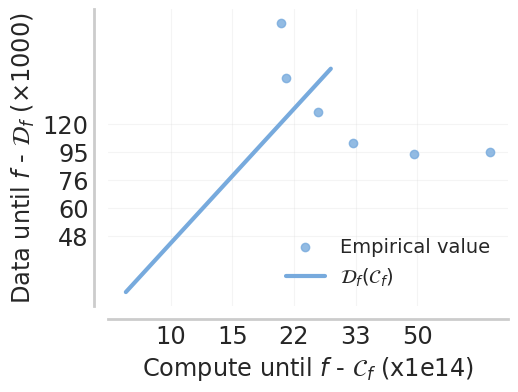

In [82]:
# Pareto fit 

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2, 369.6/192*2)

utds = np.array(utds)
data = np.mean(normalized_times_all[..., -1], axis=0) * median_median

grad_steps = utds * data
batch_sizes = 400 * (utds)**(-0.3)
compute = grad_steps * batch_sizes * 10 * 4.92e6

grad_steps_line = utd_line * data_line
batch_sizes_line = 400 * (utd_line)**(-0.3)
compute_line = grad_steps_line * batch_sizes_line * 10 * 4.92e6

# Plot the data and fit
plt.scatter(compute, data, marker='o', color=COLORS[1], label='Empirical value', alpha=0.8)
plt.plot(compute_line, data_line, COLORS[1], linewidth=3, label='$\mathcal{D}_f(\mathcal{C}_f)$')

# Plot the asymptote
# plt.axhline(y=c * median_median, color=COLORS[1], linewidth=3, linestyle='--', label='Asymptote $\mathcal{D}_{\mathrm{min}}$')

plt.xscale('log')
plt.yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False)

x = np.logspace(np.log10(1e15), np.log10(5e15), num=5, dtype=int)
x_ticks_labels = [f"{x/1e14:.0f}" for x in x]
axs.xaxis.set_minor_locator(plt.NullLocator()) 
axs.set_xticks(x,x_ticks_labels)

yticks = np.logspace(np.log10(48000), np.log10(120000), num=5, dtype=int)
ylabels = ["%2.f" % (y/1000) for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator()) 
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='Compute until $f$ - $\mathcal{C}_f$ (x1e14)',
                                       ylabel='Data until $f$ - $\mathcal{D}_f$ (×1000)',
                                       labelsize='xx-large', ticklabelsize='xx-large',
                                       grid_alpha=0.2, legend=False)


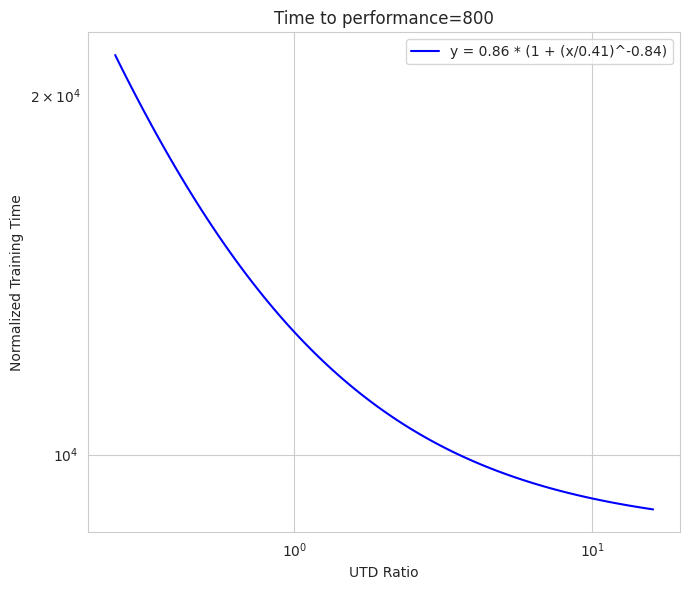

In [141]:
# Pareto fit 

plt.figure(figsize=(7, 6))
a, b, c = 0.84, 0.41, 0.86

# Generate smooth curve for plotting
utd = np.logspace(np.log10(0.25), np.log10(16), 100) 

# Plot the data and fit
plt.title('Normalized training time')
plt.plot(utd, data, 'b-', label=f'y = {c:.2f} * (1 + (x/{b:.2f})^-{a:.2f})')
# plt.axhline(y=c * 1e4, color='b', linestyle='--', label=f'Asymptote')

plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.xlabel('UTD Ratio') 
plt.ylabel('Normalized Training Time')
plt.title('Time to performance=800')
plt.legend()
plt.tight_layout()
plt.show()



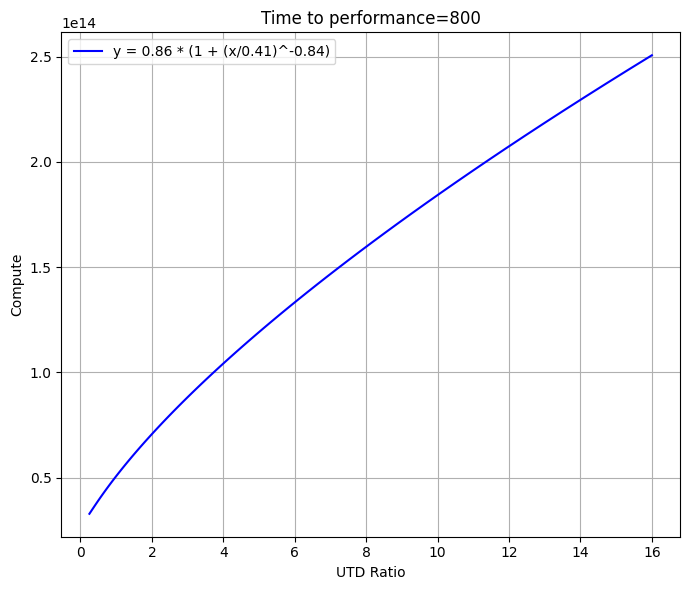

In [43]:
# Pareto fit 
def power_law_with_const(x, a, b, c): return c * (1 + (x/b)**(-a))

plt.figure(figsize=(7, 6))
a, b, c = 0.84, 0.41, 0.86

# Generate smooth curve for plotting
utd = np.logspace(np.log10(0.25), np.log10(16), 100) 
data = power_law_with_const(utd, a, b, c)
data = data * 1e4 # account for rescaling with median
grad_steps = utd * data
batch_sizes = 400 * (utd)**(-0.3)

# Plot the data and fit
plt.title('Normalized training time')
plt.plot(utd, grad_steps * batch_sizes * 10 * 1e6, 'b-', label=f'y = {c:.2f} * (1 + (x/{b:.2f})^-{a:.2f})')
# plt.axhline(y=c * 1e4, color='b', linestyle='--', label=f'Asymptote')

# plt.xscale('log')
# plt.yscale('log')
plt.grid(True)
plt.xlabel('UTD Ratio') 
plt.ylabel('Compute')
plt.title('Time to performance=800')
plt.legend()
plt.tight_layout()
plt.show()



In [29]:
1 / 0.16 * 0.84

5.25